In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

# Imputation
from sklearn.impute import KNNImputer

# For reproducibility
RANDOM_STATE = 42

import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset

In [21]:
df = pd.read_csv('diabetes.csv')

print("=" * 50)
print("DATASET SHAPE:", df.shape)
print("=" * 50)

print("\n--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe().round(2))

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Class Distribution ---")
print(df['Outcome'].value_counts())
print(f"\nClass Balance: {df['Outcome'].value_counts(normalize=True).round(3) * 100}")

print("\n--- Duplicate Rows ---")
print(f"Number of duplicates: {df.duplicated().sum()}")

DATASET SHAPE: (768, 9)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Summary Statistics ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00



--- First 5 Rows ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Class Distribution ---
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance: Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

--- Duplicate Rows ---
Number of duplicates: 0


In [22]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=" * 50)
print("ZERO VALUE ANALYSIS (Biologically Impossible Zeros)")
print("=" * 50)

zero_counts = (df[cols_with_zeros] == 0).sum()
zero_percent = ((df[cols_with_zeros] == 0).sum() / len(df) * 100).round(2)

zero_summary = pd.DataFrame({
    'Zero Count': zero_counts,
    'Zero %': zero_percent
})

print(zero_summary)

print("\n⚠️  These zeros are NOT real — they represent missing data.")
print("    We will replace them with KNN-imputed values in the cleaning step.")

ZERO VALUE ANALYSIS (Biologically Impossible Zeros)
               Zero Count  Zero %
Glucose                 5    0.65
BloodPressure          35    4.56
SkinThickness         227   29.56
Insulin               374   48.70
BMI                    11    1.43

⚠️  These zeros are NOT real — they represent missing data.
    We will replace them with KNN-imputed values in the cleaning step.


# 2. data vissualation 


FEATURE DISTRIBUTIONS BY OUTCOME


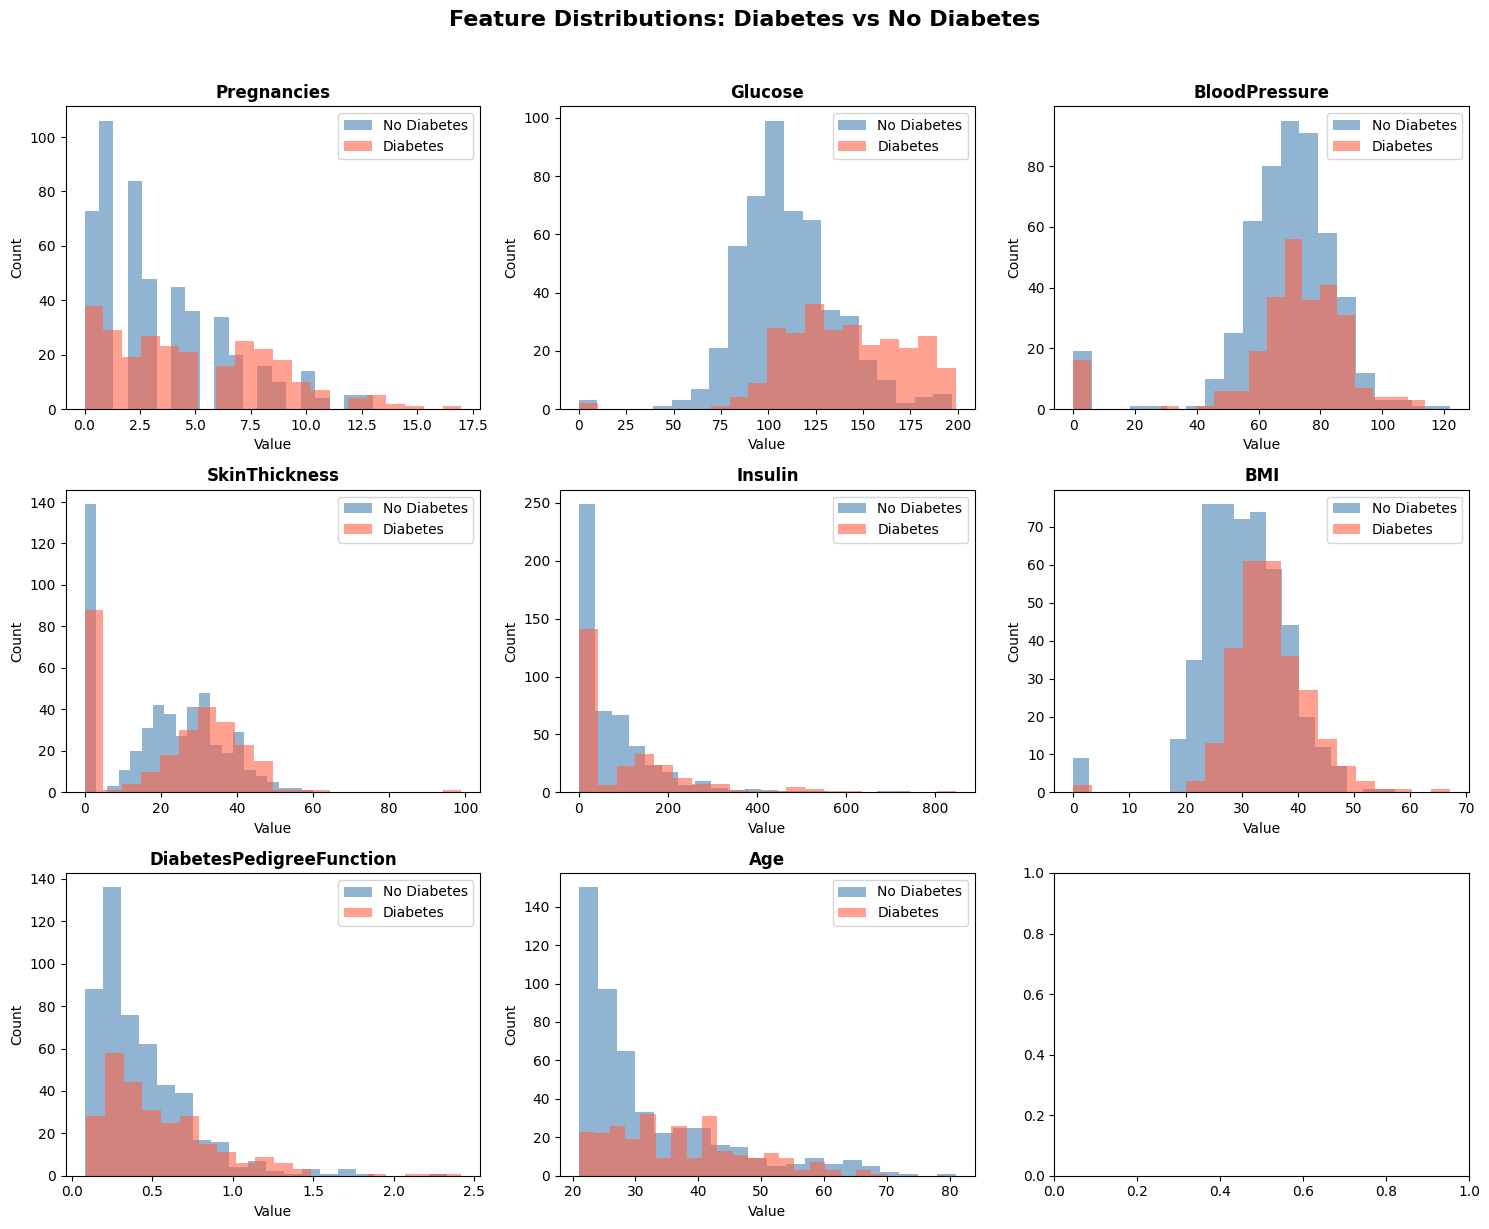

In [23]:
print("=" * 50)
print("FEATURE DISTRIBUTIONS BY OUTCOME")
print("=" * 50)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

features = df.columns[:-1]  # All columns except Outcome

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome'] == 0][col], bins=20, alpha=0.6, 
                 color='steelblue', label='No Diabetes')
    axes[i].hist(df[df['Outcome'] == 1][col], bins=20, alpha=0.6, 
                 color='tomato', label='Diabetes')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions: Diabetes vs No Diabetes', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

CORRELATION ANALYSIS


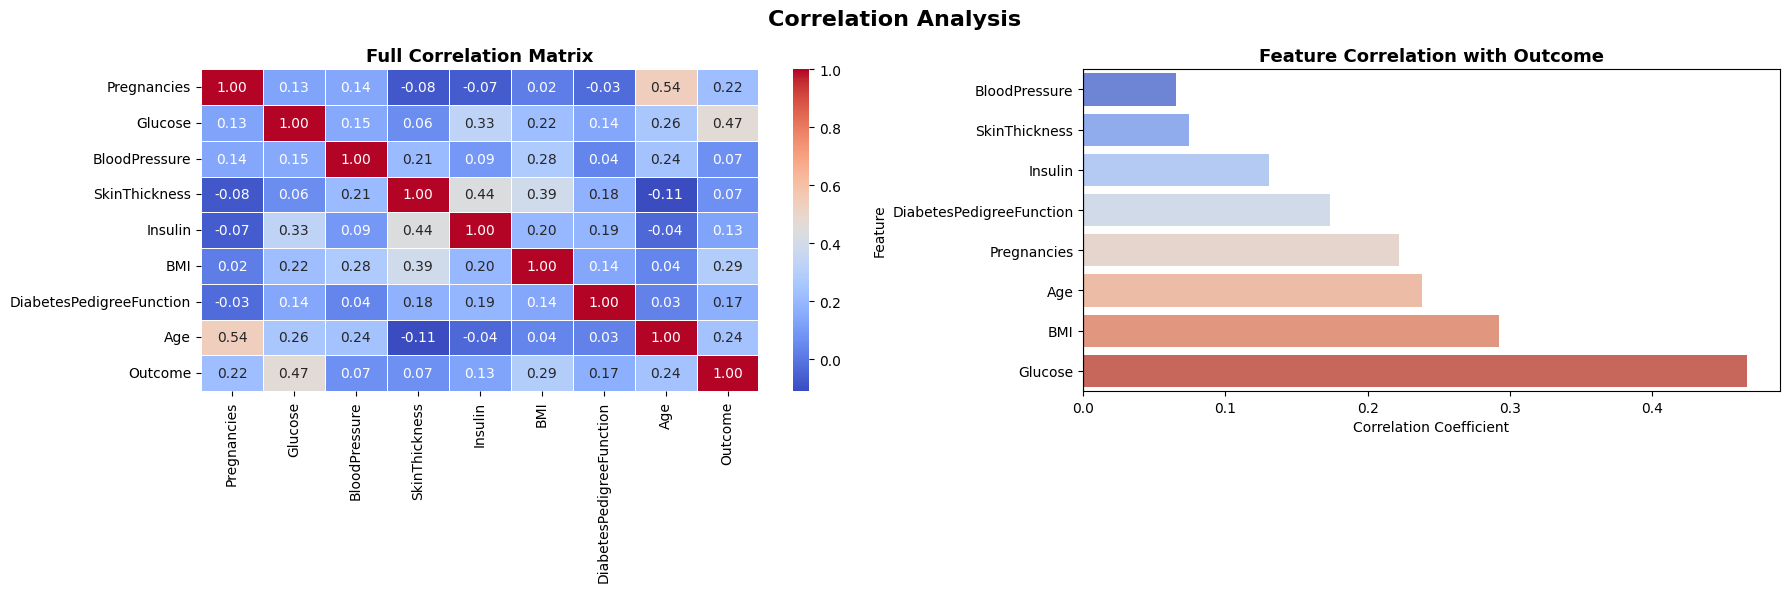


--- Top Features Correlated with Outcome ---
                          Outcome
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065


In [24]:
print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Full Correlation Heatmap ---
sns.heatmap(df.corr().round(2), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Full Correlation Matrix', fontsize=13, fontweight='bold')

# --- Plot 2: Correlation with Outcome only ---
outcome_corr = df.corr()[['Outcome']].drop('Outcome').sort_values('Outcome', ascending=True)
sns.barplot(x=outcome_corr['Outcome'], 
            y=outcome_corr.index, 
            palette='coolwarm',
            ax=axes[1])
axes[1].set_title('Feature Correlation with Outcome', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_ylabel('Feature')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlated features
print("\n--- Top Features Correlated with Outcome ---")
print(outcome_corr.sort_values('Outcome', ascending=False).round(3))

# Missing Value Imputation

MISSING VALUE IMPUTATION (KNN Imputer)

Missing values BEFORE imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values AFTER imputation:
0 missing values remaining


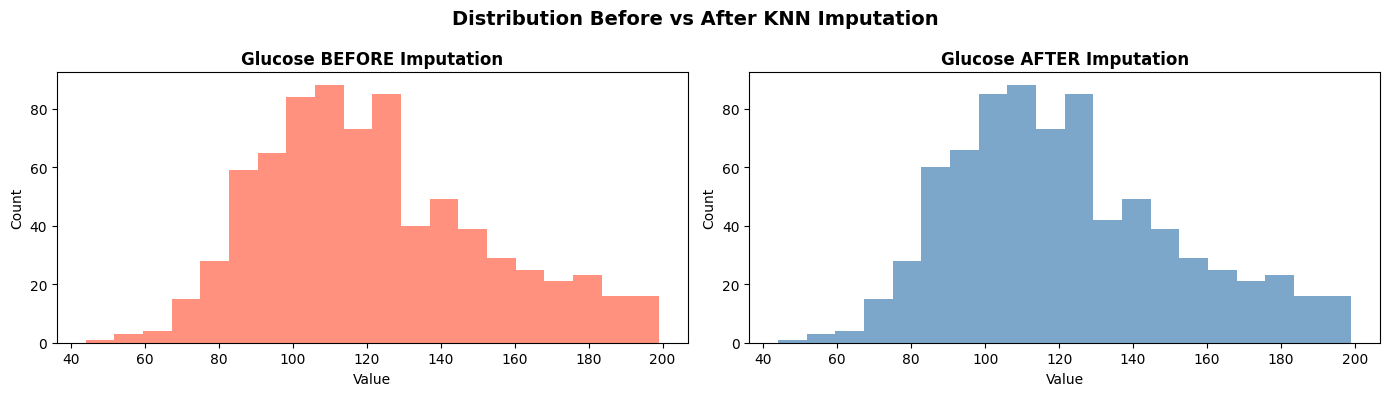


✅ Imputation complete. Using cleaned dataframe.


In [25]:
print("=" * 50)
print("MISSING VALUE IMPUTATION (KNN Imputer)")
print("=" * 50)

# Step 1: Replace 0s with NaN so KNNImputer can recognize them
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("\nMissing values BEFORE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Step 2: Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print("\nMissing values AFTER imputation:")
print(df_imputed.isnull().sum().sum(), "missing values remaining")

# Step 3: Compare before vs after for one key column
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Glucose'].dropna(), bins=20, color='tomato', alpha=0.7)
axes[0].set_title('Glucose BEFORE Imputation', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

axes[1].hist(df_imputed['Glucose'], bins=20, color='steelblue', alpha=0.7)
axes[1].set_title('Glucose AFTER Imputation', fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution Before vs After KNN Imputation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Use the imputed dataframe going forward
df = df_imputed.copy()
print("\n✅ Imputation complete. Using cleaned dataframe.")

In [26]:
print("=" * 50)
print("FEATURE & TARGET SEPARATION")
print("=" * 50)

# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Ensure target is integer type
y = y.astype(int)

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target  (y) shape: {y.shape}")

print("\n--- Feature Names ---")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

print(f"\n--- Target Distribution ---")
print(f"  No Diabetes (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Diabetes    (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

FEATURE & TARGET SEPARATION

Features (X) shape: (768, 8)
Target  (y) shape: (768,)

--- Feature Names ---
  1. Pregnancies
  2. Glucose
  3. BloodPressure
  4. SkinThickness
  5. Insulin
  6. BMI
  7. DiabetesPedigreeFunction
  8. Age

--- Target Distribution ---
  No Diabetes (0): 500 (65.1%)
  Diabetes    (1): 268 (34.9%)


In [27]:

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y        # ← Key addition
)

print(f"\nTotal samples   : {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")

print("\n--- Class Distribution After Split ---")
print(f"  Train → No Diabetes: {(y_train == 0).sum()}  | Diabetes: {(y_train == 1).sum()}")
print(f"  Test  → No Diabetes: {(y_test  == 0).sum()}  | Diabetes: {(y_test  == 1).sum()}")

print("\n--- Class Balance Check ---")
print(f"  Train diabetes rate: {y_train.mean()*100:.1f}%")
print(f"  Test  diabetes rate: {y_test.mean()*100:.1f}%")
print("\n✅ Stratification confirmed — class ratios are consistent across splits.")

TRAIN / TEST SPLIT

Total samples   : 768
Training samples: 614 (79.9%)
Testing samples : 154  (20.1%)

--- Class Distribution After Split ---
  Train → No Diabetes: 400  | Diabetes: 214
  Test  → No Diabetes: 100  | Diabetes: 54

--- Class Balance Check ---
  Train diabetes rate: 34.9%
  Test  diabetes rate: 35.1%

✅ Stratification confirmed — class ratios are consistent across splits.


In [28]:
print("=" * 50)
print("BUILDING PIPELINES")
print("=" * 50)

# --- Define Pipelines for 3 models ---
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',   # handles class imbalance
        max_iter=1000              # ensures convergence
    ))
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

pipelines = {
    'Logistic Regression'    : pipeline_lr,
    'Random Forest'          : pipeline_rf,
    'Gradient Boosting'      : pipeline_gb
}

print("\n✅ 3 Pipelines created:")
for name in pipelines:
    print(f"   → {name}")

print("\nEach pipeline:")
print("  1. Scales features with StandardScaler")
print("  2. Trains model on scaled data")
print("  3. Prevents data leakage automatically")

BUILDING PIPELINES

✅ 3 Pipelines created:
   → Logistic Regression
   → Random Forest
   → Gradient Boosting

Each pipeline:
  1. Scales features with StandardScaler
  2. Trains model on scaled data
  3. Prevents data leakage automatically


# 3. Build the Logistic Regression Model

In [29]:
print("=" * 50)
print("MODEL TRAINING & CROSS VALIDATION")
print("=" * 50)

from sklearn.model_selection import StratifiedKFold

# --- Cross Validation Setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}

for name, pipeline in pipelines.items():
    print(f"\n🔄 Training: {name}")
    
    # Cross validated scores
    acc_scores  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    roc_scores  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    f1_scores   = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    rec_scores  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')

    results[name] = {
        'Accuracy' : acc_scores.mean(),
        'ROC-AUC'  : roc_scores.mean(),
        'F1 Score' : f1_scores.mean(),
        'Recall'   : rec_scores.mean(),
    }

    print(f"   Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"   ROC-AUC  : {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")
    print(f"   F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"   Recall   : {rec_scores.mean():.4f} ± {rec_scores.std():.4f}")

# --- Summary Table ---
print("\n" + "=" * 50)
print("CROSS VALIDATION SUMMARY")
print("=" * 50)
results_df = pd.DataFrame(results).T.round(4)
display(results_df)

# --- Pick Best Model by ROC-AUC ---
best_model_name = results_df['ROC-AUC'].idxmax()
best_pipeline   = pipelines[best_model_name]
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f})")

# --- Fit best model on full training data ---
best_pipeline.fit(X_train, y_train)
print(f"\n✅ {best_model_name} fitted on full training data.")

MODEL TRAINING & CROSS VALIDATION

🔄 Training: Logistic Regression
   Accuracy : 0.7557 ± 0.0093
   ROC-AUC  : 0.8445 ± 0.0147
   F1 Score : 0.6663 ± 0.0138
   Recall   : 0.7010 ± 0.0395

🔄 Training: Random Forest
   Accuracy : 0.7590 ± 0.0199
   ROC-AUC  : 0.8240 ± 0.0201
   F1 Score : 0.6106 ± 0.0251
   Recall   : 0.5422 ± 0.0360

🔄 Training: Gradient Boosting
   Accuracy : 0.7541 ± 0.0177
   ROC-AUC  : 0.8145 ± 0.0167
   F1 Score : 0.6273 ± 0.0216
   Recall   : 0.5937 ± 0.0286

CROSS VALIDATION SUMMARY


,Accuracy,ROC-AUC,F1 Score,Recall
Logistic Regression,0.7557,0.8445,0.6663,0.7010
Random Forest,0.7590,0.8240,0.6106,0.5422
Gradient Boosting,0.7541,0.8145,0.6273,0.5937



🏆 Best Model: Logistic Regression (ROC-AUC: 0.8445)

✅ Logistic Regression fitted on full training data.


# 4. Model Evaluation

In [30]:
print("=" * 50)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 50)

# --- Define parameter grids for each model ---
param_grids = {
    'Logistic Regression': {
        'model__C'          : [0.01, 0.1, 1, 10, 100],
        'model__penalty'    : ['l1', 'l2'],
        'model__solver'     : ['liblinear']
    },
    'Random Forest': {
        'model__n_estimators'   : [100, 200, 300],
        'model__max_depth'      : [None, 5, 10],
        'model__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'model__n_estimators'   : [100, 200],
        'model__learning_rate'  : [0.01, 0.1, 0.2],
        'model__max_depth'      : [3, 5]
    }
}

# --- Run GridSearchCV on best model only ---
print(f"\n🔍 Tuning: {best_model_name}")
print("   (Running GridSearchCV — this may take a moment...)\n")

grid_search = GridSearchCV(
    estimator   = pipelines[best_model_name],
    param_grid  = param_grids[best_model_name],
    cv          = cv,
    scoring     = 'roc_auc',
    n_jobs      = -1,
    verbose     = 1
)

grid_search.fit(X_train, y_train)

# --- Results ---
print(f"\n✅ Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n🏆 Best CV ROC-AUC (before tuning): {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"🏆 Best CV ROC-AUC (after  tuning): {grid_search.best_score_:.4f}")

# --- Use tuned model going forward ---
tuned_model = grid_search.best_estimator_
print(f"\n✅ Tuned model ready for final evaluation.")

# --- Make predictions ---
print("\n--- Generating Predictions ---")
y_pred = tuned_model.predict(X_test)
y_prob = tuned_model.predict_proba(X_test)[:, 1]
print("✅ Predictions generated.")

HYPERPARAMETER TUNING (GridSearchCV)

🔍 Tuning: Logistic Regression
   (Running GridSearchCV — this may take a moment...)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Best Parameters Found:
   model__C: 0.1
   model__penalty: l2
   model__solver: liblinear

🏆 Best CV ROC-AUC (before tuning): 0.8445
🏆 Best CV ROC-AUC (after  tuning): 0.8460

✅ Tuned model ready for final evaluation.

--- Generating Predictions ---
✅ Predictions generated.


In [31]:
print("=" * 50)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 50)

# --- Core Metrics ---
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

from sklearn.metrics import f1_score, recall_score, precision_score
f1        = f1_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc:>10.4f}")
print(f"{'ROC-AUC':<25} {roc_auc:>10.4f}")
print(f"{'F1 Score':<25} {f1:>10.4f}")
print(f"{'Recall (Sensitivity)':<25} {recall:>10.4f}")
print(f"{'Precision':<25} {precision:>10.4f}")

# --- Classification Report ---
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, 
      target_names=['No Diabetes', 'Diabetes']))

# --- Compare CV score vs Test score ---
print("=" * 50)
print("CROSS VAL vs TEST SET COMPARISON")
print("=" * 50)
print(f"  CV ROC-AUC  (avg): {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"  Tuned CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"  Test ROC-AUC     : {roc_auc:.4f}")

# Check for overfitting
gap = abs(grid_search.best_score_ - roc_auc)
print(f"\n  Gap (CV vs Test) : {gap:.4f}")
if gap < 0.05:
    print("  ✅ No overfitting detected — model generalizes well.")
elif gap < 0.10:
    print("  ⚠️  Slight overfitting — model may not generalize perfectly.")
else:
    print("  ❌ Overfitting detected — consider more regularization.")

FINAL MODEL EVALUATION ON TEST SET

Metric                         Score
-------------------------------------
Accuracy                      0.7208
ROC-AUC                       0.8122
F1 Score                      0.6387
Recall (Sensitivity)          0.7037
Precision                     0.5846

--- Detailed Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.82      0.73      0.77       100
    Diabetes       0.58      0.70      0.64        54

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154

CROSS VAL vs TEST SET COMPARISON
  CV ROC-AUC  (avg): 0.8445
  Tuned CV ROC-AUC : 0.8460
  Test ROC-AUC     : 0.8122

  Gap (CV vs Test) : 0.0338
  ✅ No overfitting detected — model generalizes well.


# 5. Visualizing Results

CONFUSION MATRIX ANALYSIS

  True  Negatives (Correct No Diabetes) : 73
  False Positives (Wrong Diabetes Alert) : 27
  False Negatives (Missed Diabetes!)     : 16  ← most critical
  True  Positives (Correct Diabetes)     : 38


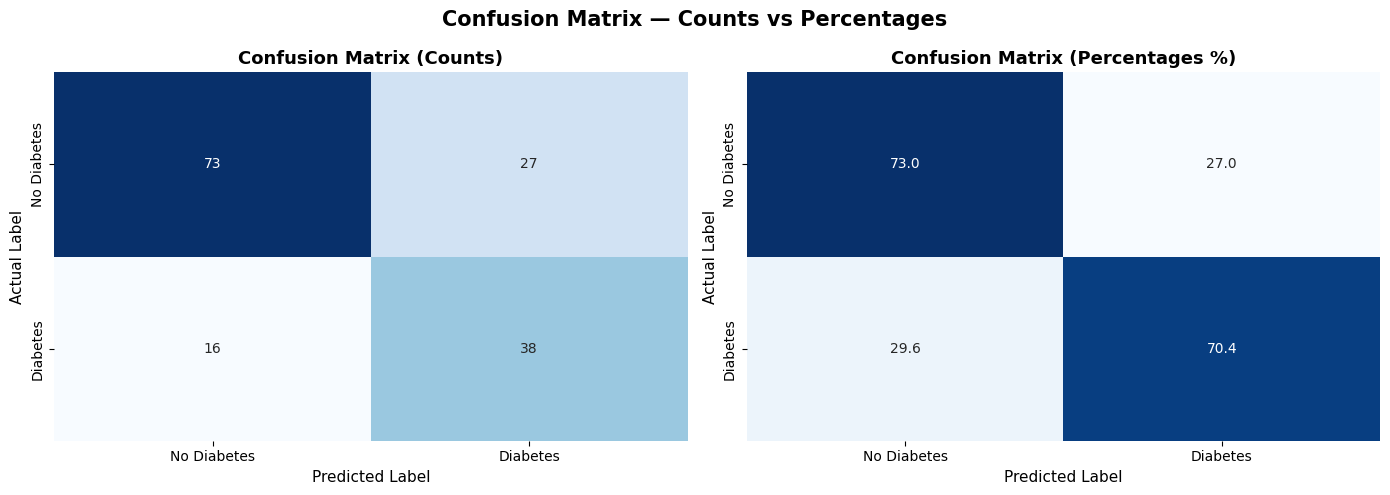


--- Medical Interpretation ---
  Of all actual diabetic patients:
  → Model correctly identified : 38/54 (70.4%)
  → Model missed               : 16/54 (29.6%)

  Of all non-diabetic patients:
  → Correctly cleared          : 73/100 (73.0%)
  → Falsely flagged            : 27/100 (27.0%)


In [34]:
print("=" * 50)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 50)

cm = confusion_matrix(y_test, y_pred)

# --- Extract values ---
tn, fp, fn, tp = cm.ravel()

print(f"\n  True  Negatives (Correct No Diabetes) : {tn}")
print(f"  False Positives (Wrong Diabetes Alert) : {fp}")
print(f"  False Negatives (Missed Diabetes!)     : {fn}  ← most critical")
print(f"  True  Positives (Correct Diabetes)     : {tp}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw counts
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Counts)', 
                   fontsize=13, fontweight='bold')

# Plot 2: Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues',
            cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            ax=axes[1])
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_title('Confusion Matrix (Percentages %)', 
                   fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix — Counts vs Percentages', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Medical Interpretation ---
print("\n--- Medical Interpretation ---")
print(f"  Of all actual diabetic patients:")
print(f"  → Model correctly identified : {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"  → Model missed               : {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"\n  Of all non-diabetic patients:")
print(f"  → Correctly cleared          : {tn}/{tn+fp} ({tn/(tn+fp)*100:.1f}%)")
print(f"  → Falsely flagged            : {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)")

ROC CURVE & FEATURE IMPORTANCE


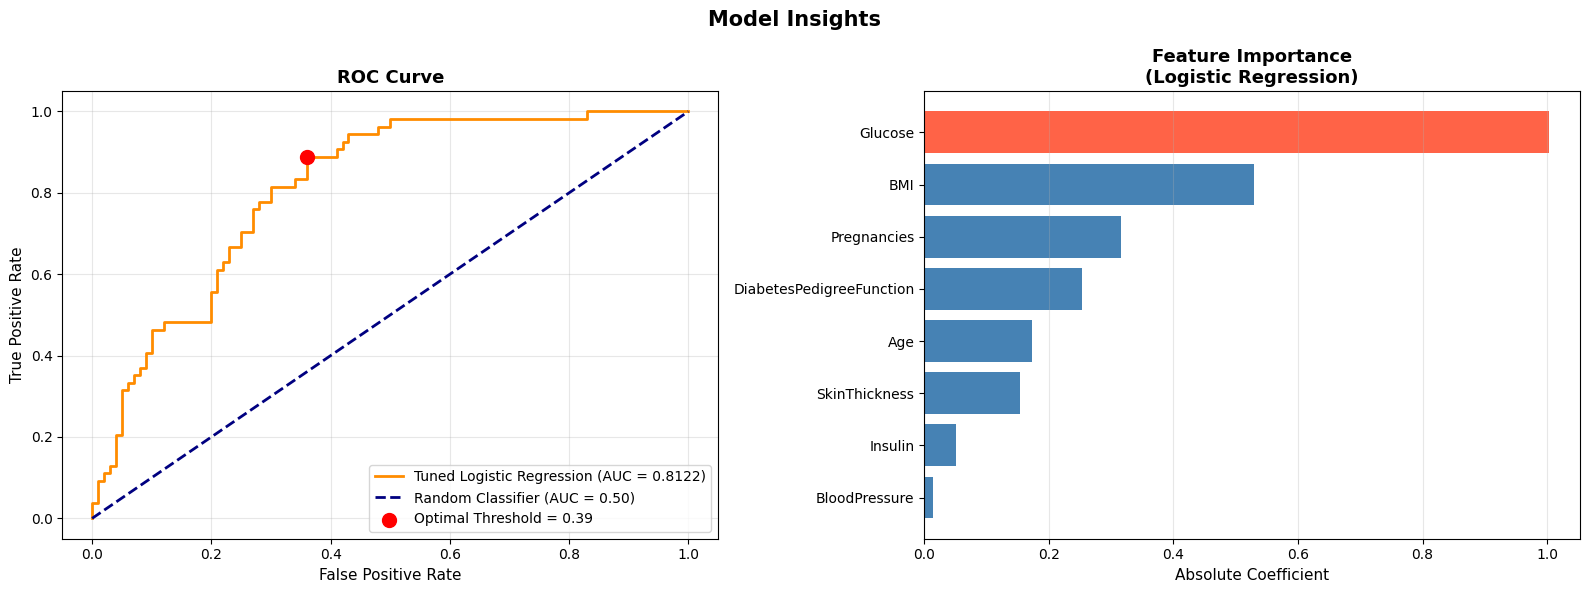


--- Feature Ranking (Most → Least Important) ---
  1. Glucose                        1.0026
  2. BMI                            0.5287
  3. Pregnancies                    0.3165
  4. DiabetesPedigreeFunction       0.2538
  5. Age                            0.1727
  6. SkinThickness                  0.1541
  7. Insulin                        0.0505
  8. BloodPressure                  0.0141

  ✅ Most important feature: Glucose
  ⚠️  Least important feature: BloodPressure

--- Optimal Decision Threshold ---
  Default threshold : 0.50
  Optimal threshold : 0.39
  → Model should predict Diabetes when probability > 0.39
  → This lower threshold catches more diabetic patients (higher recall)


In [37]:
print("=" * 50)
print("ROC CURVE & FEATURE IMPORTANCE")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Tuned {best_model_name} (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, 
             linestyle='--', label='Random Classifier (AUC = 0.50)')

# Highlight optimal threshold point
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], 
                color='red', s=100, zorder=5,
                label=f'Optimal Threshold = {optimal_threshold:.2f}')

axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# --- Plot 2: Feature Importance ---
final_model = tuned_model.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    # Tree based models (Random Forest, Gradient Boosting)
    importances = final_model.feature_importances_
    importance_type = 'Feature Importance'
else:
    # Logistic Regression
    importances = np.abs(final_model.coef_[0])
    importance_type = 'Absolute Coefficient'

feature_importance_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

colors = ['tomato' if x == feature_importance_df['Importance'].max() 
          else 'steelblue' for x in feature_importance_df['Importance']]

axes[1].barh(feature_importance_df['Feature'], 
             feature_importance_df['Importance'],
             color=colors)
axes[1].set_xlabel(importance_type, fontsize=11)
axes[1].set_title(f'Feature Importance\n({best_model_name})', 
                   fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Model Insights', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Print feature ranking ---
print("\n--- Feature Ranking (Most → Least Important) ---")
feature_importance_df_sorted = feature_importance_df.sort_values(
                               'Importance', ascending=False)
for i, row in enumerate(feature_importance_df_sorted.itertuples(), 1):
    print(f"  {i}. {row.Feature:<30} {row.Importance:.4f}")

print(f"\n  ✅ Most important feature: {feature_importance_df_sorted.iloc[0]['Feature']}")
print(f"  ⚠️  Least important feature: {feature_importance_df_sorted.iloc[-1]['Feature']}")

# --- Optimal Threshold Interpretation ---
print(f"\n--- Optimal Decision Threshold ---")
print(f"  Default threshold : 0.50")
print(f"  Optimal threshold : {optimal_threshold:.2f}")
if optimal_threshold < 0.5:
    print(f"  → Model should predict Diabetes when probability > {optimal_threshold:.2f}")
    print(f"  → This lower threshold catches more diabetic patients (higher recall)")
else:
    print(f"  → Default threshold of 0.50 is already close to optimal")

In [38]:
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(f"""
  Dataset        : Pima Indians Diabetes (768 samples)
  Best Model     : {best_model_name}
  
  --- Final Test Set Performance ---
  Accuracy       : {accuracy_score(y_test, y_pred):.4f}
  ROC-AUC        : {roc_auc_score(y_test, y_prob):.4f}
  F1 Score       : {f1_score(y_test, y_pred):.4f}
  Recall         : {recall_score(y_test, y_pred):.4f}
  Precision      : {precision_score(y_test, y_pred):.4f}

  --- Key Decisions Made ---
  ✅ KNN Imputation for missing zeros
  ✅ Stratified train/test split
  ✅ Class imbalance handled (class_weight=balanced)
  ✅ 5-Fold Stratified Cross Validation
  ✅ GridSearchCV hyperparameter tuning
  ✅ Pipeline to prevent data leakage
  ✅ Optimal threshold identified

  --- Most Important Feature ---
  🏆 {feature_importance_df_sorted.iloc[0]['Feature']}
""")

FINAL SUMMARY

  Dataset        : Pima Indians Diabetes (768 samples)
  Best Model     : Logistic Regression

  --- Final Test Set Performance ---
  Accuracy       : 0.7208
  ROC-AUC        : 0.8122
  F1 Score       : 0.6387
  Recall         : 0.7037
  Precision      : 0.5846

  --- Key Decisions Made ---
  ✅ KNN Imputation for missing zeros
  ✅ Stratified train/test split
  ✅ Class imbalance handled (class_weight=balanced)
  ✅ 5-Fold Stratified Cross Validation
  ✅ GridSearchCV hyperparameter tuning
  ✅ Pipeline to prevent data leakage
  ✅ Optimal threshold identified

  --- Most Important Feature ---
  🏆 Glucose

